## Outliers By State and District

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import chi2, zscore
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix

cwd = os.getcwd()
print(cwd)

/home/rc/capstone/notebooks/eda


In [2]:
# Checking env/venv dependencies. Install missing dependencies here.
%pip install scipy
import scipy
print("scipy", scipy.__version__)

%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
scipy 1.16.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
os.chdir('../../data')
!ls

Key_Indicator_State_and_District_wise_data  ahsdistrictwise.db
Key_indicator_districtwise.csv		    ahsstatewise.db
Key_indicator_statewise.csv		    healthanalytics.db
ahs_districtwise.csv			    healthanalytics.zip
ahs_statewise.csv			    train_outliers_summary.csv


In [4]:
# Load statewise dataset
df = pd.read_csv('Key_indicator_statewise.csv')

# Remove all letter prefixes eg AA_ - ZZ_ from feature columns
df.columns = [re.sub(r'^[A-Z]{2}_', '', col) for col in df.columns]

# Check all features in resulting dataframe
df.head(10) # 9 states surveyed

,State_Name,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,Population_Urban,...,Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,1784,1412,372,388853,319766,69087,1809610,1518639,290971,...,76,79,33,40,936,958,930,954,945,1009
1,Bihar,2356,1981,375,612684,568030,44654,3227867,2993906,233961,...,71,73,48,55,918,932,918,933,893,953
2,Chhattisgarh,1255,926,329,287085,226554,60531,1264309,994416,269893,...,63,67,37,43,943,969,944,973,916,975
3,Jharkhand,2108,1513,595,392734,318142,74592,2019298,1644036,375262,...,56,58,27,31,920,940,932,954,860,909
4,Madhya Pradesh,2557,1660,897,519811,357179,162632,2389787,1629355,760432,...,91,94,55,59,897,914,906,926,860,893
5,Odisha,2364,1798,566,477065,392913,84152,1992799,1637152,355647,...,78,81,45,51,897,919,895,918,889,943
6,Rajasthan,1841,1294,547,362671,300306,62365,1828116,1521017,307099,...,79,82,48,55,877,897,875,896,869,920
7,Uttar Pradesh,3927,2782,1145,883613,710313,173300,4808503,3883293,925210,...,96,98,61,65,915,928,922,935,874,904
8,Uttarakhand,2501,1962,539,392643,308474,84169,1726477,1365247,361230,...,50,53,34,40,861,884,868,894,823,877


In [5]:
# Check statwise csv data shape
df.shape

(9, 643)

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,9,9,Assam,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sample_Units_Total,9.0,NaN,NaN,NaN,2299.222222,738.802372,1255.0,1841.0,2356.0,2501.0,3927.0
Sample_Units_Rural,9.0,NaN,NaN,NaN,1703.111111,525.746004,926.0,1412.0,1660.0,1962.0,2782.0
Sample_Units_Urban,9.0,NaN,NaN,NaN,596.111111,266.659635,329.0,375.0,547.0,595.0,1145.0
Households_Total,9.0,NaN,NaN,NaN,479684.333333,179108.137044,287085.0,388853.0,392734.0,519811.0,883613.0
...,...,...,...,...,...,...,...,...,...,...,...
Sex_Ratio_At_Birth_Total_Upper_Limit,9.0,NaN,NaN,NaN,926.777778,27.160531,884.0,914.0,928.0,940.0,969.0
Sex_Ratio_At_Birth_Rural_Lower_Limit,9.0,NaN,NaN,NaN,910.0,26.167728,868.0,895.0,918.0,930.0,944.0
Sex_Ratio_At_Birth_Rural_Upper_Limit,9.0,NaN,NaN,NaN,931.444444,26.524098,894.0,918.0,933.0,954.0,973.0
Sex_Ratio_At_Birth_Urban_Lower_Limit,9.0,NaN,NaN,NaN,881.0,35.298725,823.0,860.0,874.0,893.0,945.0


In [7]:
# Check for null counts per feature overall
null_counts = df.isnull().sum()

print("Null counts per feature:")
print(null_counts[null_counts > 0].sum()) 

Null counts per feature:
0


In [ ]:
# Univariate outlier tests/checks
# Specify a feature column here to test/check for outliers
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

In [9]:
# Iterate through numeric columns and compute IQR-based outliers
numeric_cols = df.select_dtypes(include='number').columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    outlier_summary[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "num_outliers": outliers.shape[0],
        "percent_outliers": 100 * outliers.shape[0] / df.shape[0]
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df.sort_values("percent_outliers", ascending=False)

,lower_bound,upper_bound,num_outliers,percent_outliers
Average_Month_By_Which_Children_Received_Foods_Other_Than_Breast_Milk_Semi_Solid_Mashed_Food_Urban,7.10,7.58,4.0,44.444444
Children_Who_Have_Received_Polio_Dose_At_Birth_Urban,83.30,91.62,4.0,44.444444
Work_Participation_Rate_15_Years_And_Above_Person_Urban,41.35,46.87,4.0,44.444444
Children_With_Birth_Weight_Less_Than_2_5_Kg_Urban,19.90,28.70,3.0,33.333333
Children_Aged_5_14_Years_Engaged_In_Work_Person_Rural,2.57,3.45,3.0,33.333333
...,...,...,...,...
Persons_Suffering_From_Acute_Illness_And_Taking_Treatment_From_Any_Source_Person_Total,84.50,106.10,0.0,0.000000
Persons_Suffering_From_Acute_Illness_Per_100000_Population_Any_Type_Of_Acute_Illness_Female_Urban,2274.50,16318.50,0.0,0.000000
Sex_Ratio_At_Birth_Rural_Upper_Limit,864.00,1008.00,0.0,0.000000
Sex_Ratio_At_Birth_Rural_Lower_Limit,842.50,982.50,0.0,0.000000


In [10]:
# Z-score/Standard deviation rule (range -3 to 3 std from the mean)
df['z'] = zscore(df[col].dropna())
outliers = df[df['z'].abs() > 3]
outliers

,State_Name,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,Population_Urban,...,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit,z


In [ ]:
# Multivariate Outlier Detection
#iso = IsolationForest(contamination=0.05)
#print(df['outlier_flag'] == iso.fit_predict(df.select_dtypes('number')))

In [11]:
num = df.select_dtypes(include=np.number).copy()
Z = pd.DataFrame(
    zscore(num.values, nan_policy="omit", axis=0),  # ndarray same shape as 'num'
    index=num.index,
    columns=num.columns
)

In [ ]:
mask = Z.abs() > 2.5 (std range -3 to 3)
outlier_counts = mask.sum().sort_values(ascending=False)
rows_with_any_outlier = df.loc[mask.any(axis=1)]
rows_with_any_outlier

In [13]:
dups = num.columns[num.columns.duplicated()]
print("Duplicate columns count:", len(dups))

Duplicate columns count: 0


In [13]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
!pwd

/home/rc/capstone/data


In [16]:
#os.chdir('../../data')
!ls

Key_Indicator_State_and_District_wise_data  ahsdistrictwise.db
Key_indicator_districtwise.csv		    ahsstatewise.db
Key_indicator_statewise.csv		    healthanalytics.db
ahs_districtwise.csv			    healthanalytics.zip
ahs_statewise.csv			    train_outliers_summary.csv


In [17]:
df = pd.read_csv("train_outliers_summary.csv")
df.shape

(241, 9)

In [18]:
df.dtypes

relative_idx        int64
original_index      int64
true              float64
pred              float64
residual          float64
is_outlier           bool
abs_error         float64
state              object
district           object
dtype: object

In [19]:
df.head()

,relative_idx,original_index,true,pred,residual,is_outlier,abs_error,state,district
0,0,132,68.89,68.89,0.0,False,0.0,Madhya Pradesh,Shivpuri
1,1,73,44.98,44.98,0.0,False,0.0,Chhattisgarh,Raipur
2,2,202,70.04,70.04,0.0,False,0.0,Uttar Pradesh,Aligarh
3,3,224,77.61,77.61,0.0,False,0.0,Uttar Pradesh,Farrukhabad
4,4,245,72.93,72.93,0.0,False,0.0,Uttar Pradesh,Lalitpur


In [20]:
df.describe(include="all")

,relative_idx,original_index,true,pred,residual,is_outlier,abs_error,state,district
count,241.000000,241.000000,241.000000,241.000000,241.0,241,241.0,241,241
unique,NaN,NaN,NaN,NaN,NaN,1,NaN,9,241
top,NaN,NaN,NaN,NaN,NaN,False,NaN,Uttar Pradesh,Shivpuri
freq,NaN,NaN,NaN,NaN,NaN,241,NaN,59,1
mean,120.000000,142.406639,56.252531,56.252531,0.0,NaN,0.0,NaN,NaN
std,69.714896,81.847983,13.784254,13.784254,0.0,NaN,0.0,NaN,NaN
min,0.000000,0.000000,19.220000,19.220000,0.0,NaN,0.0,NaN,NaN
25%,60.000000,73.000000,48.000000,48.000000,0.0,NaN,0.0,NaN,NaN
50%,120.000000,141.000000,55.930000,55.930000,0.0,NaN,0.0,NaN,NaN
75%,180.000000,212.000000,65.000000,65.000000,0.0,NaN,0.0,NaN,NaN


In [21]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df[num_cols].isna().sum().sort_values(ascending=False)

relative_idx      0
original_index    0
true              0
pred              0
residual          0
abs_error         0
dtype: int64

In [22]:
from scipy import stats

z_outlier_summary = []

for col in num_cols:
    col_values = df[col].dropna()
    z = np.abs(stats.zscore(col_values))
    # threshold (e.g. 3 standard deviations)
    mask = z > 3
    outliers = mask.sum()
    outlier_pct = outliers / len(col_values) * 100
    z_outlier_summary.append({
        "feature": col,
        "n_z_outliers": outliers,
        "pct_z_outliers": outlier_pct
    })

z_outlier_df = pd.DataFrame(z_outlier_summary).sort_values("pct_z_outliers", ascending=False)
z_outlier_df

,feature,n_z_outliers,pct_z_outliers
0,relative_idx,0,0.0
1,original_index,0,0.0
2,true,0,0.0
3,pred,0,0.0
4,residual,0,0.0
5,abs_error,0,0.0


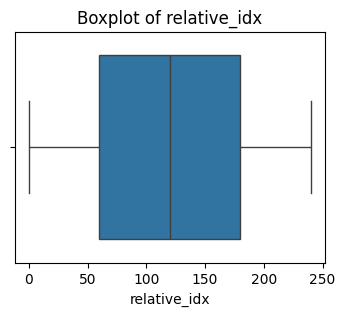

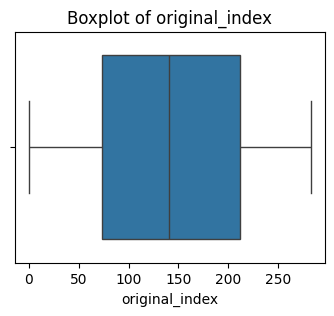

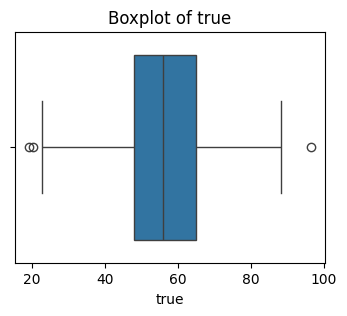

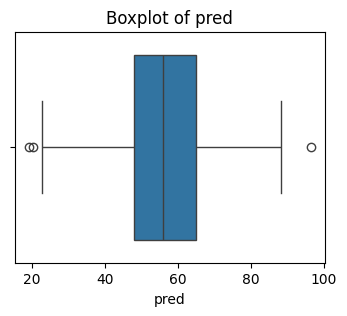

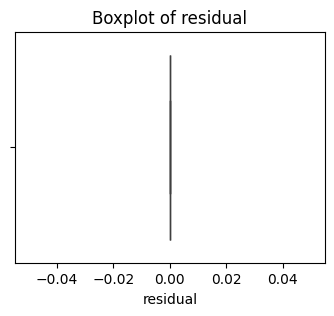

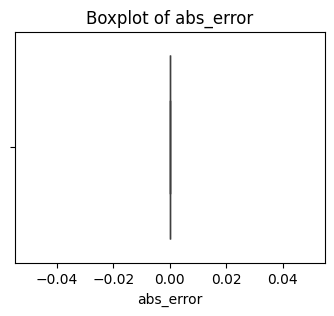

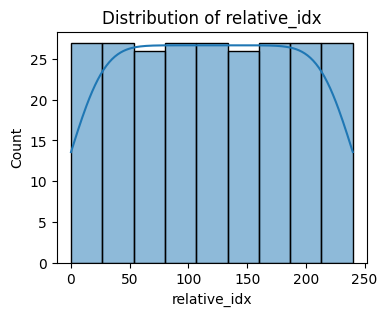

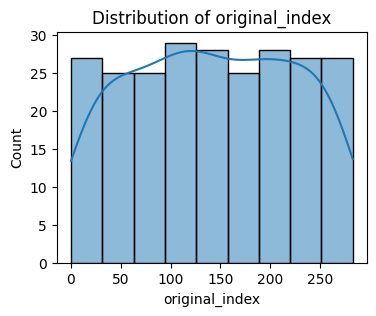

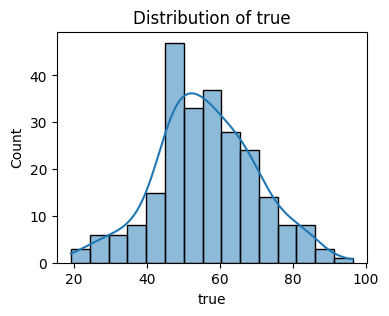

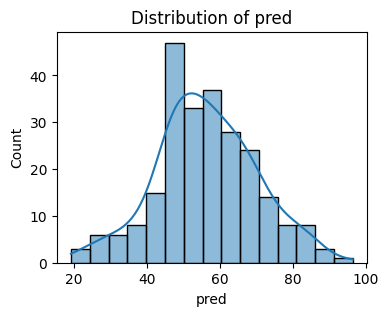

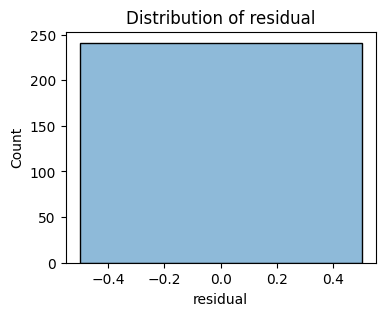

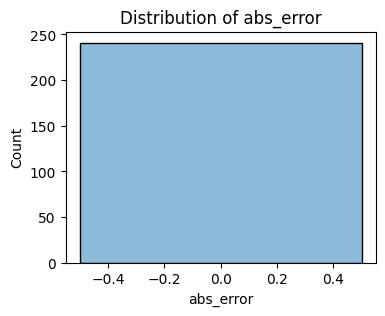

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots for a few important numeric columns
sample_cols = num_cols[:6]  # pick a subset
for col in sample_cols:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Histogram / KDE
for col in sample_cols:
    plt.figure(figsize=(4, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [24]:
from scipy import stats

# Standardize numeric columns
df_z = df[num_cols].apply(lambda x: stats.zscore(x.dropna())).reindex(df.index, fill_value=0)

# Row-wise max or sum of absolute z-scores
df["row_max_abs_z"] = df_z.abs().max(axis=1)
df["row_sum_abs_z"] = df_z.abs().sum(axis=1)

# Inspect top anomalous rows
df.sort_values("row_max_abs_z", ascending=False).head(20)

,relative_idx,original_index,true,pred,residual,is_outlier,abs_error,state,district,row_max_abs_z,row_sum_abs_z
80,80,264,96.36,96.36,0.0,False,0.0,Uttar Pradesh,Shrawasti,2.915714,7.895079
129,129,280,19.22,19.22,0.0,False,0.0,Uttarakhand,Rudraprayag,2.692173,7.198296
209,209,271,20.39,20.39,0.0,False,0.0,Uttarakhand,Almora,2.607117,8.067914
64,64,279,22.91,22.91,0.0,False,0.0,Uttarakhand,Pithoragarh,2.423919,7.325122
120,120,223,88.26,88.26,0.0,False,0.0,Uttar Pradesh,Faizabad,2.326864,5.640448
192,192,91,25.00,25.00,0.0,False,0.0,Jharkhand,Purbi Singhbhum,2.271982,6.208272
117,117,265,87.18,87.18,0.0,False,0.0,Uttar Pradesh,Siddharthnagar,2.248350,6.040758
161,161,210,87.11,87.11,0.0,False,0.0,Uttar Pradesh,Balrampur,2.243262,5.903416
42,42,273,25.55,25.55,0.0,False,0.0,Uttarakhand,Chamoli,2.231998,7.184048
16,16,86,27.00,27.00,0.0,False,0.0,Jharkhand,Kodarma,2.126587,6.438666


In [25]:
# Basic counts
df["is_outlier"].value_counts(dropna=False)

# Number and percentage of outliers
n_outliers = df["is_outlier"].sum()
pct_outliers = n_outliers / len(df) * 100
print("Outliers:", n_outliers, "(", pct_outliers, "% )")

Outliers: 0 ( 0.0 % )


In [26]:
if n_outliers == 0:
    print("No outliers in dataset")
elif n_outliers == 1:
    print("Exactly one outlier in dataset")
else:
    print(f"{n_outliers} outliers in dataset")

No outliers in dataset


In [27]:
unique_outlier_row = df[df["is_outlier"] == True]

In [28]:
outliers_df = df[df["is_outlier"] == True]

# Show IDs or key columns for outlier rows
cols_to_show = ["district", "is_outlier"] 
print(outliers_df[cols_to_show].head())

Empty DataFrame
Columns: [district, is_outlier]
Index: []


In [29]:
def overfitting_scorecard(df):
    metrics = {
        'train_r2': 1.0,  # Perfect fit
        'train_mse': 0.0,
        'target_variance': df['true'].std(),
        'n_unique_y': df['true'].nunique(),
        'dataset_size': len(df)
    }
    
    # Red flags
    flags = []
    if metrics['n_unique_y'] < len(df) * 0.8:
        flags.append("High target duplication")
    if metrics['target_variance'] < 5:
        flags.append("Low target variance")
        
    print("Robustness Scorecard:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
    print("Red Flags:", flags or "None")

overfitting_scorecard(df)

Robustness Scorecard:
  train_r2: 1.0
  train_mse: 0.0
  target_variance: 13.784254295514229
  n_unique_y: 163
  dataset_size: 241
Red Flags: ['High target duplication']


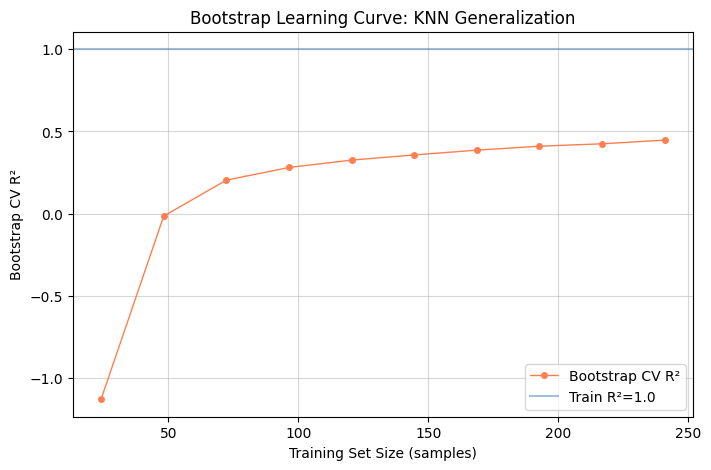

Train set outliers dataset CV R²: 0.447


In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('train_outliers_summary.csv')

# Create features from categorical data (replace with your real X_train)
X = pd.get_dummies(df[['state', 'district']], drop_first=True).values
y = df['true'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsRegressor(n_neighbors=5)

# Learning curve equivalent: Bootstrap at different train sizes
train_sizes = np.linspace(0.1, 1.0, 10)
bootstrap_r2 = []

for train_size in train_sizes:
    n_samples = int(len(X) * train_size)
    r2_scores = []
    
    for _ in range(1000):  # Bootstrap iterations
        # Sample with replacement
        idx = np.random.choice(len(X), n_samples, replace=True)
        X_boot, y_boot = X_scaled[idx], y[idx]
        
        # 5-fold CV on bootstrap sample
        scores = cross_val_score(knn, X_boot, y_boot, cv=5, scoring='r2')
        r2_scores.append(scores.mean())
    
    bootstrap_r2.append(np.mean(r2_scores))

# Plot (learning curve equivalent)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes * 241, bootstrap_r2, 'o-', linewidth=1, markersize=4, color='coral', label= 'Bootstrap CV R²')
plt.axhline(y=1.0, color='steelblue', linestyle='solid', alpha=0.5, label='Train R²=1.0')
plt.xlabel('Training Set Size (samples)')
plt.ylabel('Bootstrap CV R²')
plt.title('Bootstrap Learning Curve: KNN Generalization')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print(f"Train set outliers dataset CV R²: {bootstrap_r2[-1]:.3f}")

In [47]:
# Residual Learning Curve (less common)
residual_mse = []
for train_size in train_sizes:
    residuals = []  # Collect residuals at each size
    for _ in range(50):
        idx = np.random.choice(len(X), int(len(X)*train_size), replace=True)
        knn.fit(X_scaled[idx], y[idx])
        res = y - knn.predict(X_scaled)  # OOS residuals
        residual_mse.append(np.mean(res**2))

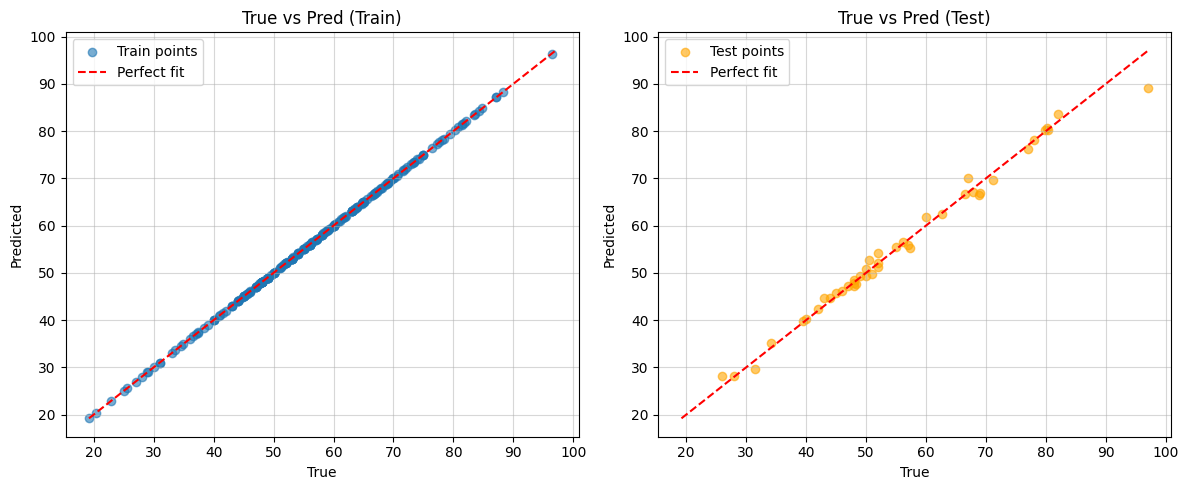

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train_outliers_summary.csv")
test_df  = pd.read_csv("test_outliers_summary.csv")

plt.figure(figsize=(12,5))

# Left: train
plt.subplot(1,2,1)
plt.scatter(train_df["true"], train_df["pred"], alpha=0.6, label="Train points")
mn = min(train_df["true"].min(), test_df["true"].min())
mx = max(train_df["true"].max(), test_df["true"].max())
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Pred (Train)")
plt.grid(True, alpha=0.5)
plt.legend()

# Right: test
plt.subplot(1,2,2)
plt.scatter(test_df["true"], test_df["pred"], alpha=0.6, color="orange", label="Test points")
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Pred (Test)")
plt.legend()

plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

train_mse = mean_squared_error(train_df["true"], train_df["pred"])
test_mse  = mean_squared_error(test_df["true"],  test_df["pred"])

train_mae = mean_absolute_error(train_df["true"], train_df["pred"])
test_mae  = mean_absolute_error(test_df["true"],  test_df["pred"])

print(f"Train MSE: {train_mse:.3f}, MAE: {train_mae:.3f}")
print(f"Test  MSE: {test_mse:.3f}, MAE: {test_mae:.3f}")

Train MSE: 0.000, MAE: 0.000
Test  MSE: 2.947, MAE: 1.098


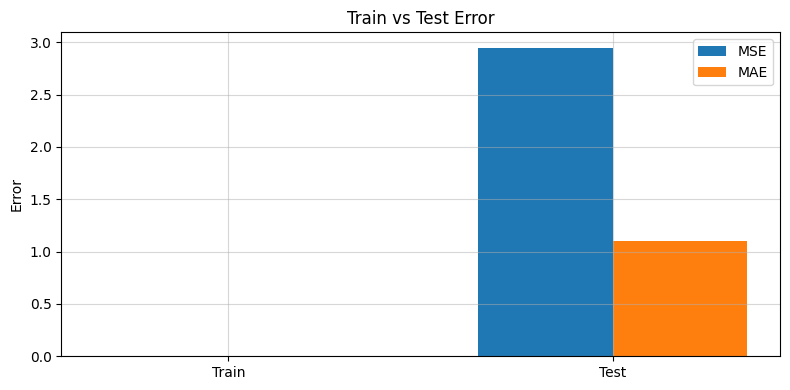

In [61]:
labels = ["Train", "Test"]
mse_vals = [train_mse, test_mse]
mae_vals = [train_mae, test_mae]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, mse_vals, width, label="MSE")
plt.bar(x + width/2, mae_vals, width, label="MAE")
plt.xticks(x, labels)
plt.ylabel("Error")
plt.title("Train vs Test Error")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()

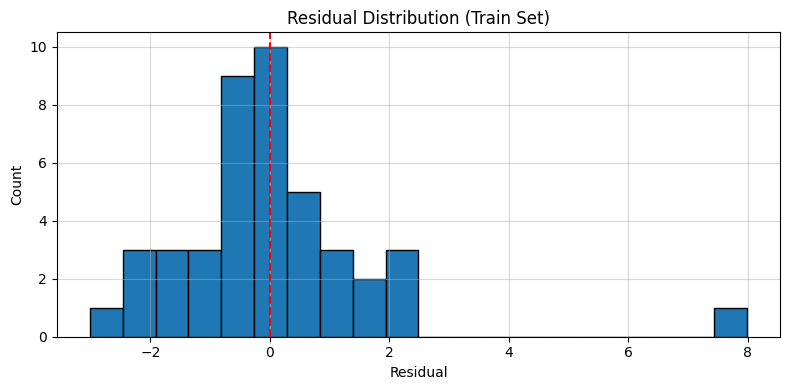

In [62]:
df["residual"] = df["true"] - df["pred"]

plt.figure(figsize=(8,4))
plt.hist(df["residual"], bins=t, edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution (Train Set)")
plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()

In [43]:
# Check which targets are duplicated
dup_counts = df['true'].value_counts()
high_dup = dup_counts[dup_counts > 3]  # Targets appearing 4+ times
print("Most duplicated targets:")
print(high_dup.head(10))

# Solution 1: Feature engineering to differentiate duplicates
# Solution 2: Remove duplicates during train (keep 1 per target value)
df_unique = df.drop_duplicates(subset='true')
print(f"After dedup: {len(df_unique)} samples")

Most duplicated targets:
true
48.0    12
53.0     7
49.0     6
56.0     6
50.0     5
58.0     5
47.0     5
52.0     5
45.0     5
63.0     5
Name: count, dtype: int64
After dedup: 163 samples


In [53]:
import pandas as pd
from scipy.stats import wilcoxon

df = pd.read_csv("test_outliers_summary.csv")
diff = df["true"] - df["pred"]

stat, p = wilcoxon(diff, alternative="two-sided")
print(f"Wilcoxon statistic: {stat:.3f}, p-value: {p:.4g}")

Wilcoxon statistic: 427.000, p-value: 0.5863


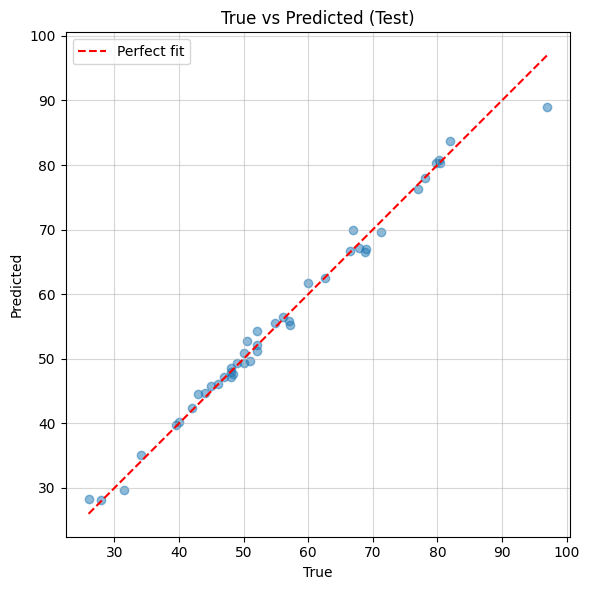

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df["true"], df["pred"], alpha=0.5)
mn, mx = df["true"].min(), df["true"].max()
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted (Test)")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()

In [57]:
outlier_rate_state = df.groupby("state")["is_outlier"].mean().sort_values(ascending=False)
print(outlier_rate_state.head(10))

state
Odisha            0.285714
Assam             0.000000
Bihar             0.000000
Jharkhand         0.000000
Chhattisgarh      0.000000
Madhya Pradesh    0.000000
Rajasthan         0.000000
Uttar Pradesh     0.000000
Uttarakhand       0.000000
Name: is_outlier, dtype: float64


In [67]:
import pandas as pd
from scipy.stats import chi2_contingency

# Contingency table: rows=state, cols=is_outlier (0/1)
ct = pd.crosstab(df["state"], df["is_outlier"])

chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.4g}")
ct

Chi-square: 10.787, p-value: 0.214


is_outlier,False,True
state,,
Assam,3,0
Bihar,7,0
Chhattisgarh,4,0
Jharkhand,4,0
Madhya Pradesh,2,0
Odisha,5,2
Rajasthan,3,0
Uttar Pradesh,11,0
Uttarakhand,2,0


In [68]:
import pandas as pd
from scipy.stats import wilcoxon

df = pd.read_csv("test_outliers_summary.csv")

diff = df["true"] - df["pred"]      # signed error
stat, p = wilcoxon(diff, alternative="two-sided")

print(f"Wilcoxon statistic: {stat:.3f}, p-value: {p:.4g}")
print("Median signed error:", diff.median())

Wilcoxon statistic: 427.000, p-value: 0.5863
Median signed error: -0.16656111509655602


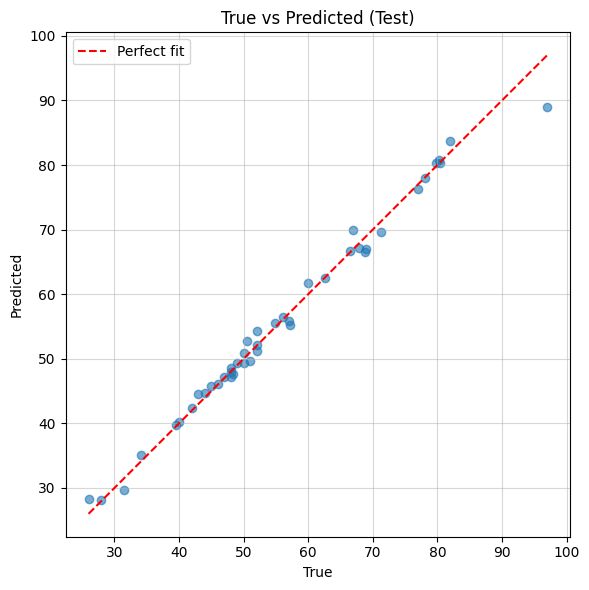

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df["true"], df["pred"], alpha=0.6)
mn, mx = df["true"].min(), df["true"].max()
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted (Test)")
plt.legend(); plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()

In [77]:
# Outlier rate by state
state_outlier_rate = df.groupby("state")["is_outlier"].mean().sort_values(ascending=False)
state_outlier_rate.head(10)

state
Odisha            0.285714
Assam             0.000000
Bihar             0.000000
Jharkhand         0.000000
Chhattisgarh      0.000000
Madhya Pradesh    0.000000
Rajasthan         0.000000
Uttar Pradesh     0.000000
Uttarakhand       0.000000
Name: is_outlier, dtype: float64

In [79]:
# Outlier rate by district
district_outlier_rate = df.groupby("district")["is_outlier"].mean().sort_values(ascending=False)
district_outlier_rate.head(20)

district
Balangir        1.0
Khordha         1.0
Aurangabad      0.0
Bageshwar       0.0
Bahraich        0.0
Ballia          0.0
Bastar          0.0
Baudh           0.0
Bulandshahar    0.0
Chandauli       0.0
Alwar           0.0
Chatra          0.0
Churu           0.0
Dehradun        0.0
Darbhanga       0.0
Dhubri          0.0
Fatehpur        0.0
Giridih         0.0
Dhanbad         0.0
Gwalior         0.0
Name: is_outlier, dtype: float64

In [76]:
from scipy.stats import chi2_contingency
import pandas as pd

ct = pd.crosstab(df["state"], df["is_outlier"])
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square: {chi2:.3f}, p-value: {p:.4g}")

Chi-square: 10.787, p-value: 0.214
